In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/button-tone-sz/columnLabels.csv
/kaggle/input/button-tone-sz/ERPdata.csv
/kaggle/input/button-tone-sz/demographic.csv
/kaggle/input/button-tone-sz/time.csv
/kaggle/input/button-tone-sz/mergedTrialData.csv
/kaggle/input/button-tone-sz/18.csv/18.csv
/kaggle/input/button-tone-sz/20.csv/20.csv
/kaggle/input/button-tone-sz/71.csv/71.csv
/kaggle/input/button-tone-sz/74.csv/74.csv
/kaggle/input/button-tone-sz/1.csv/1.csv
/kaggle/input/button-tone-sz/24.csv/24.csv
/kaggle/input/button-tone-sz/78.csv/78.csv
/kaggle/input/button-tone-sz/75.csv/75.csv
/kaggle/input/button-tone-sz/11.csv/11.csv
/kaggle/input/button-tone-sz/17.csv/17.csv
/kaggle/input/button-tone-sz/77.csv/77.csv
/kaggle/input/button-tone-sz/16.csv/16.csv
/kaggle/input/button-tone-sz/68.csv/68.csv
/kaggle/input/button-tone-sz/3.csv/3.csv
/kaggle/input/button-tone-sz/19.csv/19.csv
/kaggle/input/button-tone-sz/73.csv/73.csv
/kaggle/input/button-tone-sz/5.csv/5.csv
/kaggle/input/button-tone-sz/2.csv/2.csv
/kaggle/input/b

In [2]:
df = pd.read_csv('/kaggle/input/button-tone-sz/demographic.csv')
df

,subject,group,gender,age,education
0,1,0,M,44,16.0
1,2,0,M,39,17.0
2,3,0,M,53,18.0
3,4,0,M,52,15.0
4,5,0,M,41,16.0
...,...,...,...,...,...
76,77,1,M,28,13.0
77,78,1,F,32,16.0
78,79,1,M,37,16.0
79,80,1,M,33,13.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   subject     81 non-null     int64  
 1    group      81 non-null     int64  
 2    gender     81 non-null     object 
 3    age        81 non-null     int64  
 4    education  81 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 3.3+ KB


In [4]:
df.describe()

,subject,group,age,education
count,81.000000,81.000000,81.000000,81.000000
mean,41.000000,0.604938,39.370370,14.487654
std,23.526581,0.491910,13.594525,2.267950
min,1.000000,0.000000,19.000000,9.000000
25%,21.000000,0.000000,26.000000,13.000000
50%,41.000000,1.000000,40.000000,15.000000
75%,61.000000,1.000000,51.000000,16.000000
max,81.000000,1.000000,63.000000,19.000000


# Manually Feature Extraction

In [5]:
df_18 = pd.read_csv('/kaggle/input/button-tone-sz/18.csv/18.csv',header =None)
df_time = pd.read_csv('/kaggle/input/button-tone-sz/time.csv')
df_column = pd.read_csv('/kaggle/input/button-tone-sz/columnLabels.csv')
df_demographic = pd.read_csv('/kaggle/input/button-tone-sz/demographic.csv')

In [6]:
print(df_demographic.columns.tolist())
# Clean column names
df_demographic.columns = df_demographic.columns.str.strip() # group has a leading space so we have to clean this 


['subject', ' group', ' gender', ' age', ' education']


In [7]:
# Step 1: Assign column names to df_18 using df_column
df_18.columns = df_column.columns

# Step 2: Merge with df_time on 'sample' to add time in milliseconds
df_18 = df_18.merge(df_time, on='sample', how='left')

# Step 3: Extract metadata for subject 18 from df_demographic
subject_id = 18
subject_meta = df_demographic[df_demographic['subject'] == subject_id].iloc[0]

# Step 4: Add subject-level info (metadata) to every row in df_18
df_18['subject'] = subject_id
df_18['group'] = subject_meta['group']         # 0 = Control, 1 = Schizophrenia
df_18['age'] = subject_meta['age']
df_18['gender'] = subject_meta['gender']
df_18['education'] = subject_meta['education']

# Show result
df_18.head()


,subject,trial,condition,sample,Fp1,AF7,AF3,F1,F3,F5,...,VEOb,HEOL,HEOR,Nose,TP10,time_ms,group,age,gender,education
0,18,100.0,3.0,1.0,19.4851,17.1459,24.9083,10.6518,14.8025,11.1017,...,9.8836,6.5176,-2.5403,2.7957,-37.9614,-1500.0000,0,31,M,18.0
1,18,100.0,3.0,2.0,20.8405,17.5713,24.9541,9.8642,14.0010,11.2620,...,9.5141,6.6881,-0.8424,2.7754,-40.0404,-1499.0234,0,31,M,18.0
2,18,100.0,3.0,3.0,20.1618,16.5537,25.5364,9.5530,13.9523,11.9496,...,8.3634,7.7335,-0.2069,3.0363,-40.6820,-1498.0469,0,31,M,18.0
3,18,100.0,3.0,4.0,16.0048,13.3988,22.2583,7.6258,11.3477,10.8981,...,6.9158,5.5133,-1.1496,2.1566,-39.1204,-1497.0703,0,31,M,18.0
4,18,100.0,3.0,5.0,11.8484,9.5153,18.3010,6.1650,8.6445,9.1772,...,5.9214,-0.2537,-1.6079,4.0425,-38.6995,-1496.0938,0,31,M,18.0


In [8]:
# Step 1: Choose EEG channels (excluding meta columns)
eeg_channels = df_column.columns[4:]  # Skip ['subject', 'trial', 'condition', 'sample']

# Step 2: Create a dictionary to hold each trial's EEG matrix
trials = {}

# Step 3: Group df_18 by trial
for trial_num, trial_df in df_18.groupby('trial'):
    eeg_data = trial_df[eeg_channels].values.T  # Shape: [channels x time]
    trials[int(trial_num)] = eeg_data


In [9]:
# Print shape of one trial (e.g., trial 1)
print("Trial 1 EEG shape:", trials[1].shape)  # Example: (64 channels, 3072 time points)


Trial 1 EEG shape: (70, 6144)


In [10]:
import numpy as np
import pandas as pd
import pywt
from scipy.stats import skew, kurtosis
from scipy.signal import welch

# Simulate a single EEG trial shape (70 channels x 6144 samples)
np.random.seed(42)
eeg_data = np.random.randn(70, 6144)

# Frequency bands (Hz)
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 100),
}

# Sampling rate (from time.csv: ~0.976 ms/sample → ~1024 Hz)
fs = 1024  

def extract_features(eeg_trial, fs):
    features = []
    for channel_data in eeg_trial:
        # Statistical features
        features += [
            np.mean(channel_data),
            np.std(channel_data),
            skew(channel_data),
            kurtosis(channel_data),
            np.min(channel_data),
            np.max(channel_data),
            np.median(channel_data),
        ]

        # Spectral features using Welch PSD
        freqs, psd = welch(channel_data, fs)
        for band in bands.values():
            idx = np.logical_and(freqs >= band[0], freqs <= band[1])
            features.append(np.sum(psd[idx]))

        # Wavelet features (using 'db4', 5-level decomposition)
        coeffs = pywt.wavedec(channel_data, 'db4', level=5)
        for c in coeffs:
            features.append(np.mean(c))
            features.append(np.std(c))
    return features

# Extract features from the simulated EEG trial
trial_features = extract_features(eeg_data, fs)

# Generate feature column names
feature_names = []
for ch in range(70):
    feature_names += [
        f"ch{ch}_mean", f"ch{ch}_std", f"ch{ch}_skew", f"ch{ch}_kurt", 
        f"ch{ch}_min", f"ch{ch}_max", f"ch{ch}_median"
    ]
    feature_names += [f"ch{ch}_{band}_power" for band in bands]
    for w in range(6):  # 6 wavelet coefficient sets from level 5 decomposition
        feature_names.append(f"ch{ch}_w{w}_mean")
        feature_names.append(f"ch{ch}_w{w}_std")

# Convert features to DataFrame and add dummy label
df_features = pd.DataFrame([trial_features], columns=feature_names)
df_features["label"] = 1  # Example label (1 = Schizophrenia)

# Save to CSV (Kaggle-safe path)
csv_path = "./eeg_features_example.csv"
df_features.to_csv(csv_path, index=False)

print(f"CSV file saved at: {csv_path}")

CSV file saved at: ./eeg_features_example.csv


In [11]:
# Section: Helper - Generate Column Names
def generate_column_names():
    names = []
    for ch in range(70):
        names += [f"ch{ch}_mean", f"ch{ch}_std", f"ch{ch}_skew", f"ch{ch}_kurt", f"ch{ch}_min", f"ch{ch}_max", f"ch{ch}_median"]
        names += [f"ch{ch}_{band}_power" for band in bands]
        names += [f"ch{ch}_w{w}_mean" for w in range(6)]
        names += [f"ch{ch}_w{w}_std" for w in range(6)]
    return names


In [12]:
all_features = []
labels = []
subject_ids = []

trial_length = 6144  # Number of rows per trial
valid_subjects = range(1, 82)

for subject_id in valid_subjects:
    file_path = f"/kaggle/input/button-tone-sz/{subject_id}.csv/{subject_id}.csv"
    
    if not os.path.exists(file_path):
        continue

    try:
        df = pd.read_csv(file_path, header=None)
        data = df.values[:, 4:]  # Remove metadata: keep only EEG channels (cols 4 onward)

        # Reshape into trials
        total_samples = data.shape[0]
        n_trials = total_samples // trial_length
        data = data[:n_trials * trial_length]  # Truncate overflow
        trials = data.reshape(n_trials, trial_length, -1)  # shape: (n_trials, 6144, 70)

        for trial in trials:
            trial = trial.T  # Shape it as (channels, time) = (70, 6144)
            features = extract_features(trial, fs)
            all_features.append(features)
            labels.append(df_demographic[df_demographic["subject"] == subject_id]["group"].values[0])
            subject_ids.append(subject_id)
    
    except Exception as e:
        print(f"❌ Error for subject {subject_id}: {e}")


In [13]:
#Section: Save Full Feature Dataset to CSV
df_features = pd.DataFrame(all_features, columns=generate_column_names())
df_features["label"] = labels
df_features["subject"] = subject_ids

df_features.to_csv("eeg_all_features.csv", index=False)
print("✔️ Saved as eeg_all_features.csv")


✔️ Saved as eeg_all_features.csv


In [14]:
# Convert features and labels to DataFrame
df_all_features = pd.DataFrame(all_features)
df_all_features["label"] = labels  # Binary labels (0 = Control, 1 = Schizophrenia)


In [15]:
# Check if features and labels were collected
print("✅ Total EEG feature vectors extracted:", len(all_features))
print("✅ Total labels collected:", len(labels))

# Optional: Check a few labels
print("🔍 First 5 labels:", labels[:5])


✅ Total EEG feature vectors extracted: 5756
✅ Total labels collected: 5756
🔍 First 5 labels: [0, 0, 0, 0, 0]


In [16]:
import os

data_dir = "/kaggle/input/button-tone-sz"
available_dirs = [name for name in os.listdir(data_dir) if name.endswith(".csv")]

valid_subjects = []

for dirname in available_dirs:
    try:
        subject_id = int(dirname.replace(".csv", ""))
        file_path = os.path.join(data_dir, dirname, f"{subject_id}.csv")
        if os.path.exists(file_path):
            valid_subjects.append(subject_id)
    except:
        continue  # Skip if folder name is not a number

print(f"✅ Total valid EEG files found: {len(valid_subjects)}")


✅ Total valid EEG files found: 40


In [17]:
# ——— Build full paths to each subject’s CSV ———
eeg_files = [
    os.path.join(data_dir, dirname, f"{dirname.replace('.csv','')}.csv")
    for dirname in available_dirs
    if os.path.exists(os.path.join(data_dir, dirname, f"{dirname.replace('.csv','')}.csv"))
]
print(f"✅ Total EEG files found: {len(eeg_files)}")


✅ Total EEG files found: 40


In [18]:
# Make sure these are not empty first
print(len(all_features), len(labels), len(subject_ids))  # should all be > 0

# Save the data properly
df_features = pd.DataFrame(all_features, columns=generate_column_names())
df_features["label"] = labels
df_features["subject"] = subject_ids

df_features.to_csv("eeg_all_features.csv", index=False)
print("✔️ Saved eeg_all_features.csv with shape:", df_features.shape)


5756 5756 5756
✔️ Saved eeg_all_features.csv with shape: (5756, 1682)


In [19]:
df_all_features = pd.read_csv("eeg_all_features.csv")
X = df_all_features.drop(columns=["label", "subject"])
y = df_all_features["label"]

In [20]:
# Shape and structure
print(f"Dataset shape: {df_all_features.shape}")
df_all_features.info()

# Check for missing values
missing_values = df_all_features.isnull().sum()
print("Missing values:\n", missing_values[missing_values > 0])




Dataset shape: (5756, 1682)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5756 entries, 0 to 5755
Columns: 1682 entries, ch0_mean to subject
dtypes: float64(1680), int64(2)
memory usage: 73.9 MB
Missing values:
 Series([], dtype: int64)


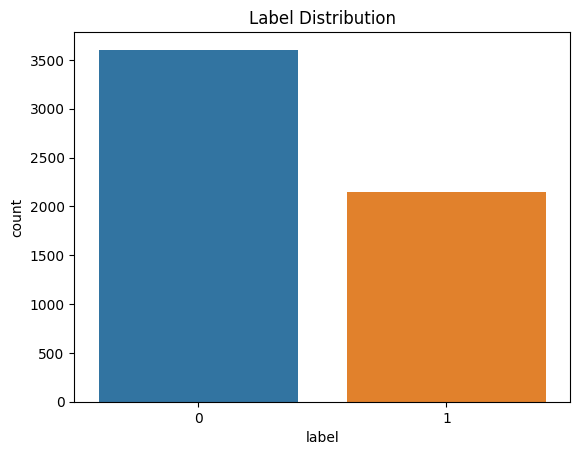

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df_all_features)
plt.title('Label Distribution')
plt.show()


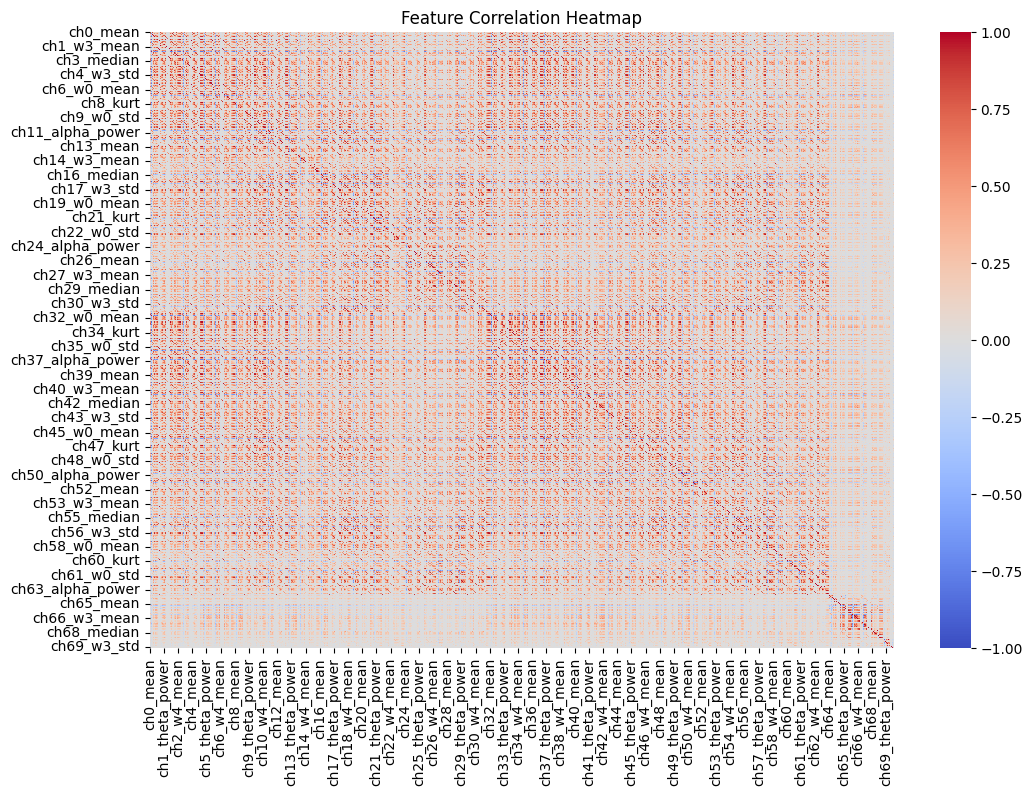

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_all_features.drop(columns=['subject']).corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()


In [23]:
from sklearn.model_selection import train_test_split

# Now this should work
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training samples: {len(X_train)}")
print(f"✅ Testing samples: {len(X_test)}")


✅ Training samples: 4604
✅ Testing samples: 1152


In [24]:
from sklearn.model_selection import train_test_split

# Load the full feature dataset (if not already loaded)
df_all_features = pd.read_csv("eeg_all_features.csv")

# Separate features (X) and target label (y)
X = df_all_features.drop(columns=["label", "subject"])  # Drop subject column too
y = df_all_features["label"]

# Check if dataset is non-empty
if len(df_all_features) == 0:
    raise ValueError("❌ No data found in eeg_all_features.csv. Cannot split.")

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training samples: {len(X_train)}")
print(f"✅ Testing samples: {len(X_test)}")


✅ Training samples: 4604
✅ Testing samples: 1152


# ML MODELS

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


### Random forest

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Define parameter grid for Random Forest
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Step 2: Set up Grid Search with 5-fold CV and AUC scoring
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(estimator=rf, param_grid=rf_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Step 3: Fit Grid Search on training data
rf_grid.fit(X_train, y_train)

# Step 4: Use best model
best_rf = rf_grid.best_estimator_
print("✅ Best Parameters:", rf_grid.best_params_)

# Step 5: Predict on test set using the best model
y_pred = best_rf.predict(X_test)

# Step 6: Evaluate
print("🔍 Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
🔍 Accuracy: 0.9956597222222222
📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       721
           1       1.00      0.99      0.99       431

    accuracy                           1.00      1152
   macro avg       1.00      1.00      1.00      1152
weighted avg       1.00      1.00      1.00      1152



In [27]:
# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(6, 4))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Control", "Schizophrenia"], yticklabels=["Control", "Schizophrenia"])
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("🧠 Confusion Matrix - Random Forest")
# plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


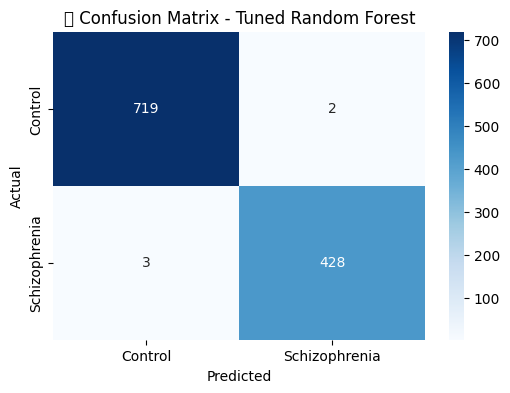

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


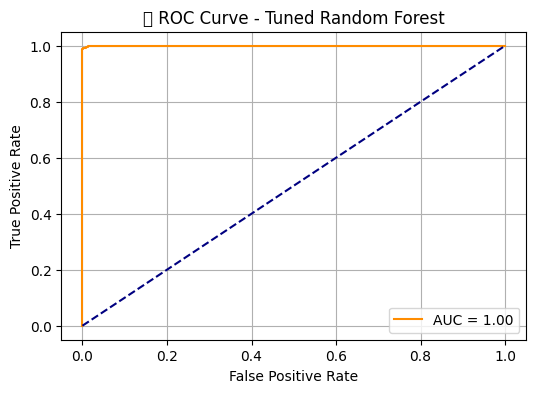

✅ AUC Score: 0.9997


In [28]:
# # Probability scores for positive class (label=1)
# y_proba = rf_clf.predict_proba(X_test)[:, 1]

# # ROC Curve
# fpr, tpr, _ = roc_curve(y_test, y_proba)
# auc_score = roc_auc_score(y_test, y_proba)

# plt.figure(figsize=(6, 4))
# plt.plot(fpr, tpr, color="darkorange", label=f"AUC = {auc_score:.2f}")
# plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("📈 ROC Curve - Random Forest")
# plt.legend(loc="lower right")
# plt.grid()
# plt.show()

# print(f"✅ AUC Score: {auc_score:.4f}")
# Use the best estimator

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Control", "Schizophrenia"],
            yticklabels=["Control", "Schizophrenia"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("🧠 Confusion Matrix - Tuned Random Forest")
plt.show()

# Probability scores for positive class (label=1)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("📈 ROC Curve - Tuned Random Forest")
plt.legend(loc="lower right")
plt.grid()
plt.show()

print(f"✅ AUC Score: {auc_score:.4f}")


In [29]:
from sklearn.preprocessing import StandardScaler

# Refit the scaler on the entire dataset (best practice before saving)
scaler = StandardScaler()
scaler.fit(X)  # X should be the full feature set (not split)

# Now save
import joblib

joblib.dump(best_rf, "tuned_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model and Scaler saved successfully!")


✅ Model and Scaler saved successfully!


### Feature Importance (Interpretability)

/tmp/ipykernel_13/1619275098.py:13: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


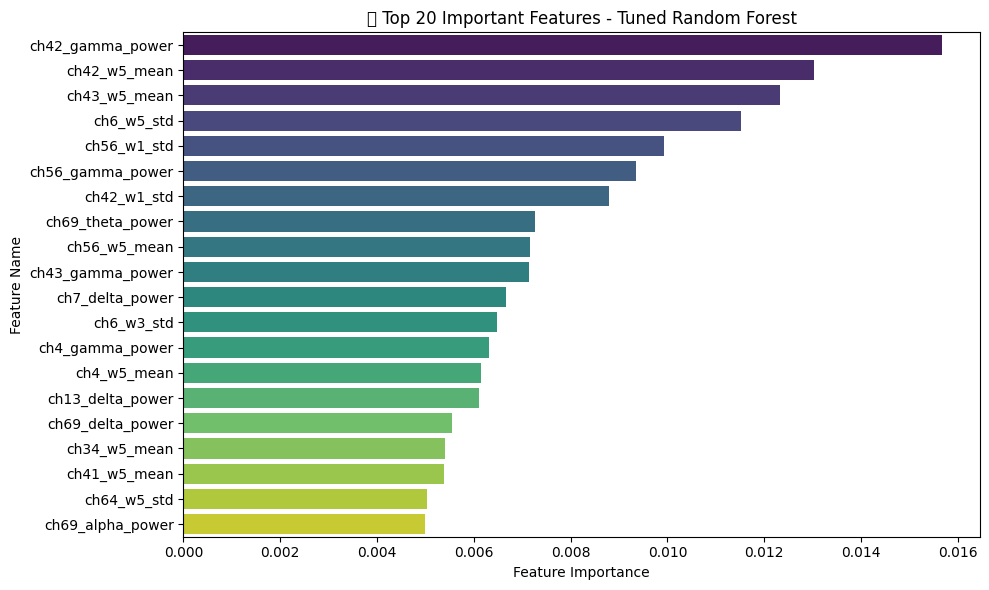

In [30]:
# Feature importance from best (tuned) Random Forest
importances = best_rf.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_df = feature_df.sort_values(by="Importance", ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_df.head(20), palette="viridis")
plt.title("🔍 Top 20 Important Features - Tuned Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


In [31]:
import joblib
import pandas as pd
import numpy as np

# Load saved model and scaler
model = joblib.load("tuned_rf_model.pkl")
scaler = joblib.load("scaler.pkl")

# Simulate new data (or load from CSV)
# Replace this with: pd.read_csv("new_data.csv") for real use
new_data = pd.read_csv("eeg_all_features.csv").drop(columns=["label", "subject"])
new_data_scaled = scaler.transform(new_data)

# Predict class (0=Control, 1=Schizophrenia)
predictions = model.predict(new_data_scaled)
probabilities = model.predict_proba(new_data_scaled)[:, 1]

# Show output
output_df = pd.DataFrame({
    "Prediction": predictions,
    "Probability_Schizophrenia": probabilities
})

output_df.head()


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,Prediction,Probability_Schizophrenia
0,0,0.431000
1,0,0.394750
2,0,0.419500
3,0,0.454750
4,0,0.395167


## Comparision of ML Models

In [32]:
# Define Evaluation Function
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
import time

def evaluate_model(model, model_name):
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "AUC": auc,
        "F1": report["weighted avg"]["f1-score"],
        "Time (s)": round(end - start, 2)
    }


In [33]:
# train all the models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Define all models
models = [
    (RandomForestClassifier(random_state=42), "Random Forest"),
    (SVC(kernel="rbf", probability=True, random_state=42), "SVM"),
    (LogisticRegression(max_iter=1000, random_state=42), "Logistic Regression"),
    (XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), "XGBoost")
]

# Evaluate and store results
results = [evaluate_model(model, name) for model, name in models]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy       AUC        F1  Time (s)
3              XGBoost  0.993924  0.999788  0.993922     14.04
0        Random Forest  0.995660  0.999698  0.995657     20.87
2  Logistic Regression  0.978299  0.990473  0.978294     16.14
1                  SVM  0.835069  0.940459  0.824313    104.60


/tmp/ipykernel_13/634024194.py:16: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


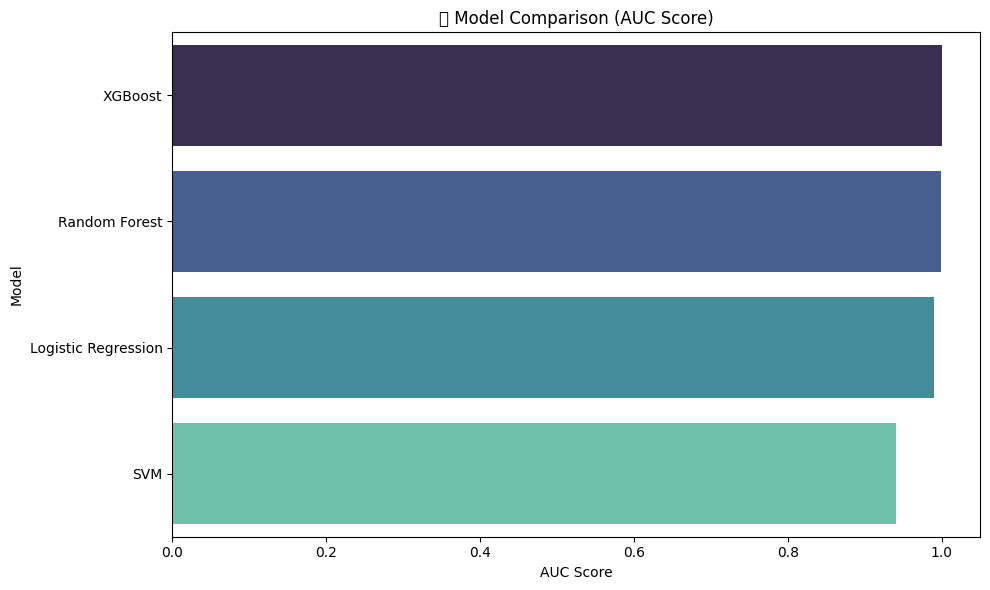

In [34]:
# Compare All Models

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display sorted by AUC
results_df = results_df.sort_values(by="AUC", ascending=False)
print(results_df)

# Plot comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="AUC", y="Model", data=results_df, palette="mako")
plt.title("📈 Model Comparison (AUC Score)")
plt.xlabel("AUC Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


# Deep learning Model

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


2025-06-06 12:28:59.041040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749212939.300192      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749212939.371920      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [37]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')  # Binary classification
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-06 12:29:16.499832: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [38]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop,lr_reduce],
    verbose=1
)


Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6745 - auc: 0.7206 - loss: 0.6019 - val_accuracy: 0.9066 - val_auc: 0.9664 - val_loss: 0.2590 - learning_rate: 0.0010
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8982 - auc: 0.9593 - loss: 0.2591 - val_accuracy: 0.9718 - val_auc: 0.9960 - val_loss: 0.0916 - learning_rate: 0.0010
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9557 - auc: 0.9895 - loss: 0.1276 - val_accuracy: 0.9685 - val_auc: 0.9964 - val_loss: 0.0861 - learning_rate: 0.0010
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9621 - auc: 0.9941 - loss: 0.0982 - val_accuracy: 0.9870 - val_auc: 0.9977 - val_loss: 0.0443 - learning_rate: 0.0010
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9754 - auc: 0.9960 - loss: 0.0727 - val_accuracy: 0.9881 - val_auc: 0.9961 - val_loss: 0.0522 - learning_rate: 0.0010
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9800 - 

In [40]:
loss, accuracy, auc = model.evaluate(X_test_scaled, y_test,verbose=0)
print(f"✅ Test Accuracy: {accuracy:.4f}")
print(f"📈 Test AUC: {auc:.4f}")



✅ Test Accuracy: 0.9948
📈 Test AUC: 0.9979


### Cross val Score manually

In [41]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

# Use all data
X_all_scaled = scaler.fit_transform(X)
y_all = np.array(y)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
auc_scores = []

for train_idx, val_idx in kf.split(X_all_scaled, y_all):
    X_train_fold, X_val_fold = X_all_scaled[train_idx], X_all_scaled[val_idx]
    y_train_fold, y_val_fold = y_all[train_idx], y_all[val_idx]

    # Recreate your model architecture
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_fold.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=30,
        batch_size=32,
        verbose=0
    )

    y_val_pred = (model.predict(X_val_fold) > 0.5).astype("int32")
    y_val_prob = model.predict(X_val_fold)

    acc_scores.append(accuracy_score(y_val_fold, y_val_pred))
    auc_scores.append(roc_auc_score(y_val_fold, y_val_prob))

print(f"\n✅ Average Cross-Validation Accuracy: {np.mean(acc_scores):.4f}")
print(f"📈 Average Cross-Validation AUC: {np.mean(auc_scores):.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

✅ Average Cross-Validation Accuracy: 0.9957
📈 Average Cross-Validation AUC: 0.9998


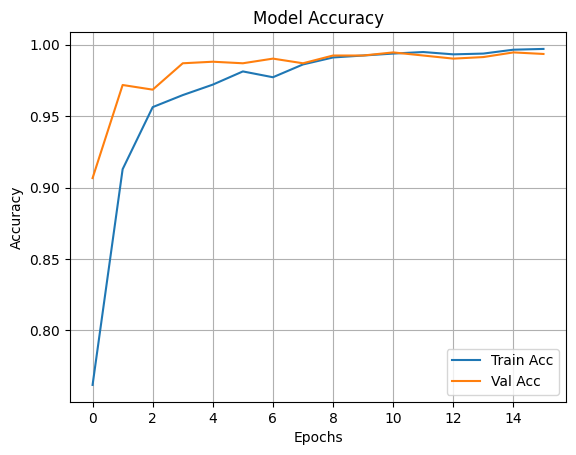

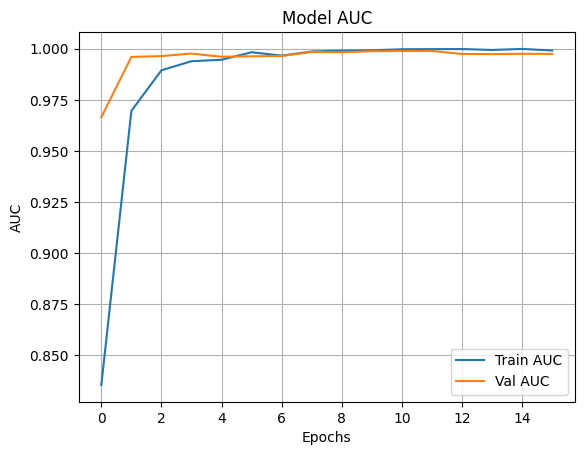

In [42]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot AUC
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('Model AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid()
plt.show()


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


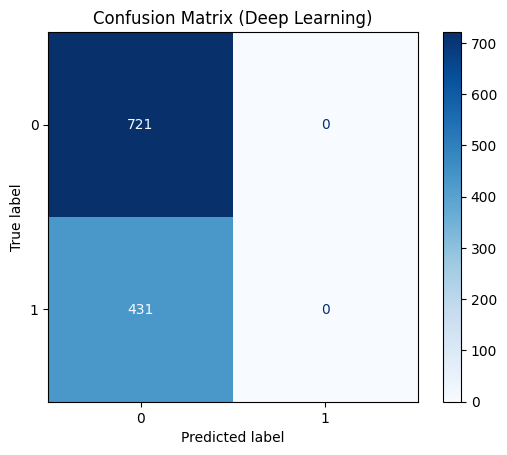

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_dl = model.predict(X_test).argmax(axis=1)  # for one-hot
# or use threshold if sigmoid + binary: y_pred_dl = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred_dl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Deep Learning)")
plt.show()


# Feature extraction through ML and training through DL

In [44]:
# Step-by-step: Feature Extraction via Autoencoder + DL Training

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load your feature dataset
features_df = pd.read_csv("eeg_all_features.csv")
X = features_df.drop(columns=["label", "subject"])
y = features_df["label"]

# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Autoencoder model for feature learning
input_dim = X_train.shape[1]
encoding_dim = 32  # compressed feature size

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(encoding_dim, activation="relu")(encoded)

decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(1e-3), loss="mse")
autoencoder.fit(X_train, X_train,
                epochs=50,
                batch_size=64,
                shuffle=True,
                validation_split=0.2,
                callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
                verbose=1)

# 5. Extract compressed features
encoder = Model(input_layer, encoded)
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

# 6. Train Deep Learning model using compressed features
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(encoding_dim,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', 'AUC'])

history = model.fit(
    X_train_encoded, y_train,
    validation_data=(X_test_encoded, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

# 7. Evaluate
loss, accuracy, auc = model.evaluate(X_test_encoded, y_test, verbose=0)
print(f"\n✅ DL Model on Autoencoder Features")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.8411 - val_loss: 0.5869
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4958 - val_loss: 0.4776
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4025 - val_loss: 0.4191
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3720 - val_loss: 0.3846
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3475 - val_loss: 0.3548
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3026 - val_loss: 0.3376
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2938 - val_loss: 0.3260
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2890 - val_loss: 0.3159
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2915 - val_loss: 0.3074
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2785 - val_loss: 0.3023
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2695 - val_loss: 0.2973
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2551 - val

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - AUC: 0.5317 - accuracy: 0.5401 - loss: 1.3373 - val_AUC: 0.7031 - val_accuracy: 0.6944 - val_loss: 0.5956
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.6020 - accuracy: 0.6072 - loss: 0.7184 - val_AUC: 0.7695 - val_accuracy: 0.7318 - val_loss: 0.5623
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.6519 - accuracy: 0.6653 - loss: 0.6216 - val_AUC: 0.8021 - val_accuracy: 0.7509 - val_loss: 0.5295
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.7109 - accuracy: 0.6773 - loss: 0.5882 - val_AUC: 0.8189 - val_accuracy: 0.7613 - val_loss: 0.5142
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.7481 - accuracy: 0.7039 - loss: 0.5552 - val_AUC: 0.8160 - val_accuracy: 0.7613 - val_loss: 0.4961
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.7458 - accuracy: 0.7175 - loss: 0.5473 - val_AUC: 0.8364 - val_accuracy: 0.7743 - val_loss: 0.4757
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.7847